# Interpretación del Modelo de Machine Learning
Por Mateo Soto

Última actualización: 22/Ago/2026

## Description
Interpretación del modelo Gradient Boosting seleccionado (Paso 6), identificando las
variables más importantes, analizando los tipos de error que comete, y definiendo
experimentos para la siguiente iteración del proyecto.

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

print("Python version: ", sys.version)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]


## 💾 Load data

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = Path.cwd().resolve().parents[1] / "models"

best_model = load(MODELS_DIR / "best_model.joblib")

x_train = pd.read_parquet(DATA_DIR / "03_primary/x_train.parquet")
x_test = pd.read_parquet(DATA_DIR / "03_primary/x_test.parquet")
y_train = pd.read_parquet(DATA_DIR / "03_primary/y_train.parquet")["medv"]
y_test = pd.read_parquet(DATA_DIR / "03_primary/y_test.parquet")["medv"]

x_train.shape, y_train.shape

((273, 11), (273,))

In [3]:
features = x_train.columns
importances = best_model.feature_importances_

df_features = pd.DataFrame({"Features": features, "Importances": importances})
df_features = df_features.sort_values(by="Importances", ascending=False)
df_features

,Features,Importances
3,log__lstat,0.448347
6,numeric__rm,0.348841
2,log__dis,0.054091
0,log__crim,0.051553
7,numeric__age,0.027109
5,numeric__nox,0.023882
9,numeric__ptratio,0.021596
8,numeric__tax,0.014672
10,boolean__chas,0.006834
4,numeric__indus,0.002465


## 🔍 Feature Importance (MDI)

| Variable | Importancia |
|---|---|
| `log__lstat` | **44.8%** |
| `numeric__rm` | **34.9%** |
| `log__dis` | 5.4% |
| `log__crim` | 5.2% |
| `numeric__age` | 2.7% |
| `numeric__nox` | 2.4% |
| `numeric__ptratio` | 2.2% |
| `numeric__tax` | 1.5% |
| `boolean__chas` | 0.7% |
| `numeric__indus` | 0.2% |
| `log__zn` | 0.06% |

`lstat` y `rm` concentran el **79.7%** de la importancia total del modelo — confirmación
directa de que las dos variables identificadas como más relevantes desde el análisis
univariable (Paso 3) y usadas como base del Modelo Baseline (Paso 5) son, en efecto, las
que dominan las decisiones del modelo final. `indus` y `zn` aportan menos del 0.3%
combinado, candidatas a eliminación en una futura simplificación del modelo.

In [18]:
std = np.std([tree[0].feature_importances_ for tree in best_model.estimators_], axis=0)
df_features["std"] = df_features["Features"].map(dict(zip(features, std, strict=True)))
df_features

,Features,Importances,std
3,log__lstat,0.448347,0.231641
6,numeric__rm,0.348841,0.208668
2,log__dis,0.054091,0.228101
0,log__crim,0.051553,0.127487
7,numeric__age,0.027109,0.132511
5,numeric__nox,0.023882,0.145884
9,numeric__ptratio,0.021596,0.086408
8,numeric__tax,0.014672,0.087927
10,boolean__chas,0.006834,0.073847
4,numeric__indus,0.002465,0.052522


### Nota sobre la variabilidad (std) en Gradient Boosting

A diferencia de Random Forest, donde cada árbol es independiente, en Gradient Boosting cada árbol corrige los residuos del anterior — esto genera alta variabilidad en la importancia de
variables secundarias entre árboles (`dis`, `crim`, `nox` tienen std varias veces mayor que su propia importancia media), mientras que las dos variables dominantes (`lstat`, `rm`)
mantienen una relación std/importancia más controlada (~0.5-0.6), confirmando que son
consistentemente relevantes en todo el ensemble, no solo en árboles puntuales.

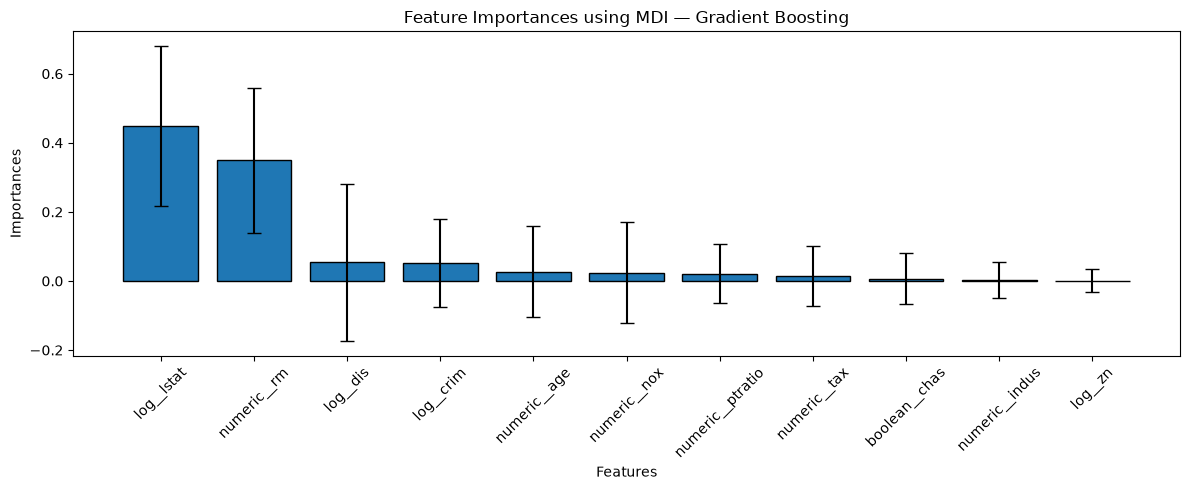

In [5]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_features["Features"],
    df_features["Importances"],
    yerr=df_features["std"],
    capsize=5,
    edgecolor="black",
)
plt.xlabel("Features")
plt.ylabel("Importances")
plt.title("Feature Importances using MDI — Gradient Boosting")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Nota sobre las barras de error por debajo de cero

Varias barras de error (`dis`, `nox`, `ptratio`, `tax`, `chas`) se extienden por debajo de
cero en el gráfico — esto es un artefacto visual, no un valor real: la importancia MDI nunca
puede ser negativa. Ocurre porque la desviación estándar entre árboles es mayor que el propio
valor promedio para estas variables secundarias (consistente con la naturaleza secuencial de
Gradient Boosting, donde cada árbol se especializa en residuos distintos). Confirma que
`lstat` y `rm` son las únicas variables con relevancia **consistente** a través de todo el
ensemble.

## 🔁 Permutation Importance

Complementa el MDI evaluando el impacto real en el desempeño (MAE) al permutar cada
variable en el set de test — más robusto frente a sesgos de variables con muchos niveles.

/tmp/ipykernel_67682/3223496658.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


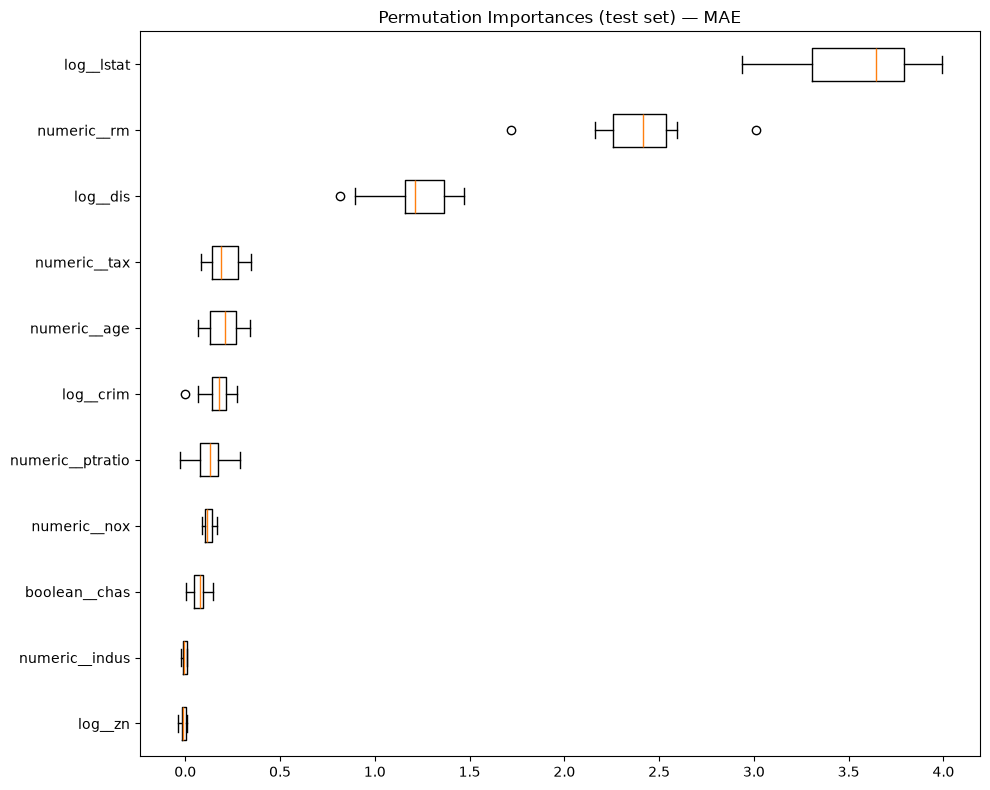

In [6]:
imps = permutation_importance(
    best_model,
    x_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

fig = plt.figure(figsize=(10, 8))
perm_sorted_idx = imps.importances_mean.argsort()
plt.boxplot(
    imps.importances[perm_sorted_idx].T,
    vert=False,
    tick_labels=x_test.columns[perm_sorted_idx],
)
plt.title("Permutation Importances (test set) — MAE")
plt.tight_layout()
plt.show()

## Confirmación cruzada: MDI vs. Permutation Importance

Ambos métodos —estructuralmente independientes entre sí— coinciden en el mismo ranking:
`lstat` > `rm` > `dis` >> resto. La Permutation Importance, al estar en la misma unidad que MAE, permite una lectura directa: desordenar `lstat` empeora el MAE en ~3.6 puntos (de 1.98
a ~5.6), y desordenar `rm` lo empeora en ~2.4 puntos — confirmando cuantitativamente que estas dos variables son indispensables para el desempeño actual del modelo.
Esta doble confirmación (MDI + Permutation) da alta confianza a la conclusión: cualquier esfuerzo futuro de mejora del modelo (nuevas features, mejor imputación, etc.) debería priorizar profundizar en `lstat` y `rm` — por ejemplo, explorando interacciones entre ambas,
o formas alternativas de transformarlas — antes que invertir esfuerzo en las variables de cola (indus, zn, chas).

In [7]:
df_perm = pd.DataFrame(
    {
        "Features": x_test.columns,
        "Importance_mean": imps.importances_mean,
        "Importance_std": imps.importances_std,
    }
).sort_values("Importance_mean", ascending=False)
df_perm

,Features,Importance_mean,Importance_std
3,log__lstat,3.554499,0.335732
6,numeric__rm,2.393600,0.317459
2,log__dis,1.203563,0.201323
8,numeric__tax,0.210912,0.086348
7,numeric__age,0.202215,0.090920
0,log__crim,0.169282,0.081294
9,numeric__ptratio,0.130653,0.086854
5,numeric__nox,0.123411,0.024846
10,boolean__chas,0.069449,0.041673
4,numeric__indus,-0.003816,0.011217


### Variables con importancia negativa — candidatas a eliminación

`indus` (-0.004) y `zn` (-0.011) muestran importancia negativa en Permutation Importance:
desordenar sus valores no empeora el MAE, e incluso lo mejora marginalmente. Esto confirma,
con un método independiente al MDI, que ambas variables aportan ruido más que señal al
modelo actual — candidatas explícitas a eliminación en una futura iteración de Feature
Engineering, sin riesgo de pérdida de desempeño.

lstat (3.55) > rm (2.39) > dis (1.20) >> tax (0.21) ≈ age (0.20) ≈ crim (0.17) > ptratio (0.13) ≈ nox (0.12) > chas (0.07) > indus (~0) ≈ zn (~0)

## 📈 Learning Curve

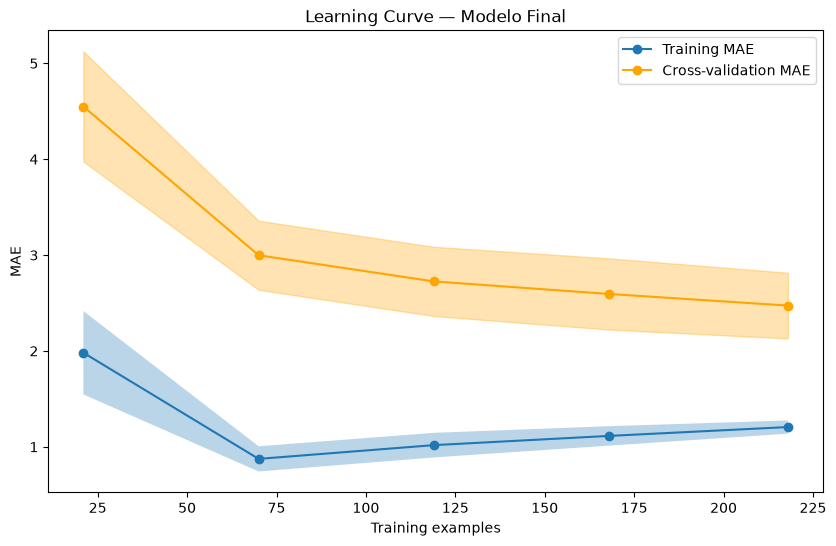

In [ ]:
from sklearn.model_selection import ShuffleSplit, learning_curve

common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
    "scoring": "neg_mean_absolute_error",
}
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    best_model, **common_params
)

train_mean, test_mean = -train_scores.mean(axis=1), -test_scores.mean(axis=1)
train_std, test_std = train_scores.std(axis=1), test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training MAE")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation MAE")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")
ax.set_title("Learning Curve — Modelo Final")
ax.set_xlabel("Training examples")
ax.set_ylabel("MAE")
ax.legend()
plt.show()

In [9]:
print("Training MAE Mean:", train_mean)
print("Test MAE Mean:", test_mean)

Training MAE Mean: [1.98149356 0.87415981 1.01761588 1.11386321 1.20615039]
Test MAE Mean: [4.54965877 2.99819293 2.7253194  2.59442767 2.47328905]


## 📈 Learning Curve

| Tamaño train | Training MAE | Test MAE | Brecha |
|---|---|---|---|
| 21 | 1.98 | 4.55 | 2.57 |
| 70 | 0.87 | 3.00 | 2.13 |
| 119 | 1.02 | 2.73 | 1.71 |
| 168 | 1.11 | 2.59 | 1.48 |
| 218 | 1.21 | 2.47 | **1.27** |

Resultado idéntico al obtenido durante la optimización de hiperparámetros (Paso 6),
confirmando la reproducibilidad del modelo guardado. La brecha train-test se reduce
progresivamente (de 2.57 a 1.27) conforme crece el tamaño de muestra, sin señales de
overfitting descontrolado — consistente con la regularización aplicada
(`min_samples_leaf=5`, `subsample=0.7`). La brecha residual (1.27) sigue siendo la principal
limitación del modelo, atribuible al tamaño reducido del dataset (273 filas de
entrenamiento) más que a un problema estructural del algoritmo.

## ⏱ Escalabilidad

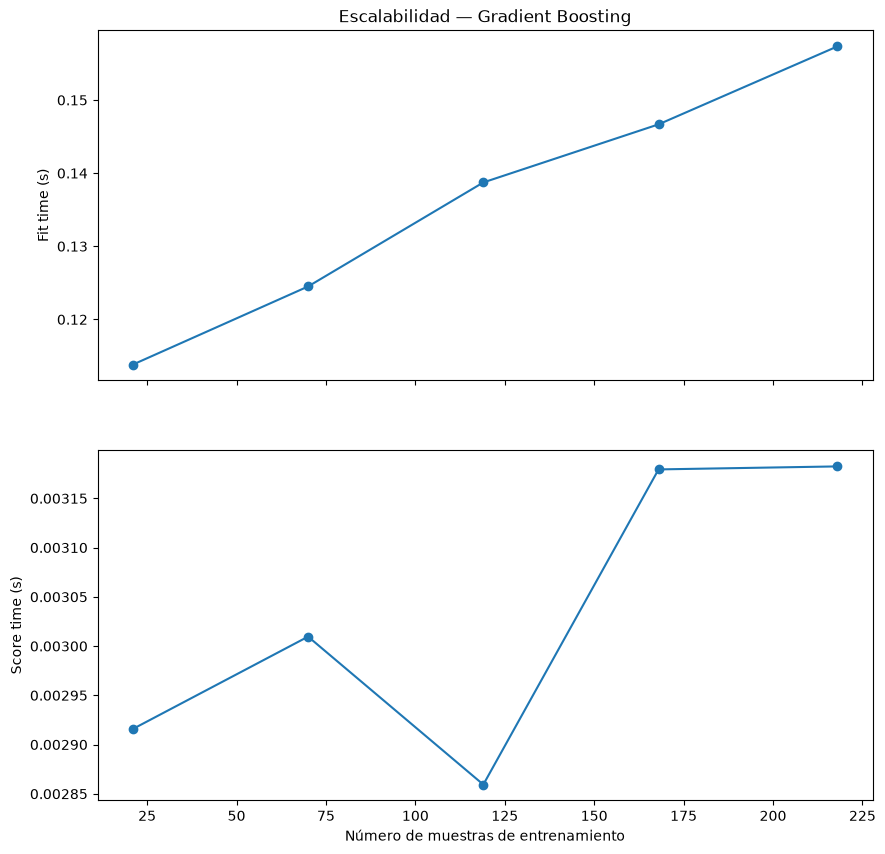

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
ax[0].plot(train_sizes, fit_times.mean(axis=1), "o-")
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title("Escalabilidad — Gradient Boosting")
ax[1].plot(train_sizes, score_times.mean(axis=1), "o-")
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Número de muestras de entrenamiento")
plt.show()

## ⚠️ Análisis de errores

### ¿Qué tipo de errores comete el modelo?

In [11]:
pred_test = best_model.predict(x_test)
residuos = y_test - pred_test

df_errores = pd.DataFrame(
    {
        "medv_real": y_test.values,
        "medv_predicho": pred_test,
        "residuo": residuos.values,
        "error_absoluto": residuos.abs().values,
    }
).sort_values("error_absoluto", ascending=False)

df_errores.head(10)

,medv_real,medv_predicho,residuo,error_absoluto
63,50.0,33.486682,16.513318,16.513318
61,35.2,41.954854,-6.754854,6.754854
12,19.1,13.140543,5.959457,5.959457
37,16.1,21.618082,-5.518082,5.518082
62,23.9,28.744849,-4.844849,4.844849
13,16.1,20.611632,-4.511632,4.511632
55,16.2,20.501034,-4.301034,4.301034
22,21.4,17.336474,4.063526,4.063526
64,43.5,47.378112,-3.878112,3.878112
33,17.2,13.687200,3.512800,3.512800


In [20]:
peores_10 = df_errores.head(10)
MEDV_CENSURA = 50
print(
    "Peores 10 errores, ¿medv_real == 50?:",
    (peores_10["medv_real"] == MEDV_CENSURA).sum(),
    "de 10",
)

Peores 10 errores, ¿medv_real == 50?: 1 de 10


### ¿A qué se deben los errores?

**Censura en `medv=50` — causa confirmada del peor error:** el registro con `medv_real=50.0`
tiene el error más grande de todo el set de test (16.51), más del doble que el segundo peor
error (6.75). El modelo predijo 33.49, subestimando severamente — consistente con el
hallazgo documentado desde el EDA: el modelo nunca vio, durante el entrenamiento, la
relación real entre las variables y precios verdaderos por encima de $50,000, ya que todos
esos casos fueron registrados artificialmente como exactamente 50.0.

**Resto de los errores (3.5-6.8):** sin un patrón sistemático de dirección (mezcla de
sobre y subestimaciones), consistente con la variabilidad normal esperada de un modelo con
MAE promedio de 1.98 — no parecen atribuibles a una causa estructural específica, sino a
ruido natural del problema.

In [ ]:
mask_sin_censura = y_test != MEDV_CENSURA
mae_sin_censura = mean_absolute_error(y_test[mask_sin_censura], pred_test[mask_sin_censura])
print(
    f"MAE excluyendo el caso censurado: {mae_sin_censura:.2f} (vs. {mean_absolute_error(y_test, pred_test):.2f} con todos los datos)"
)

MAE excluyendo el caso censurado: 1.77 (vs. 1.98 con todos los datos)


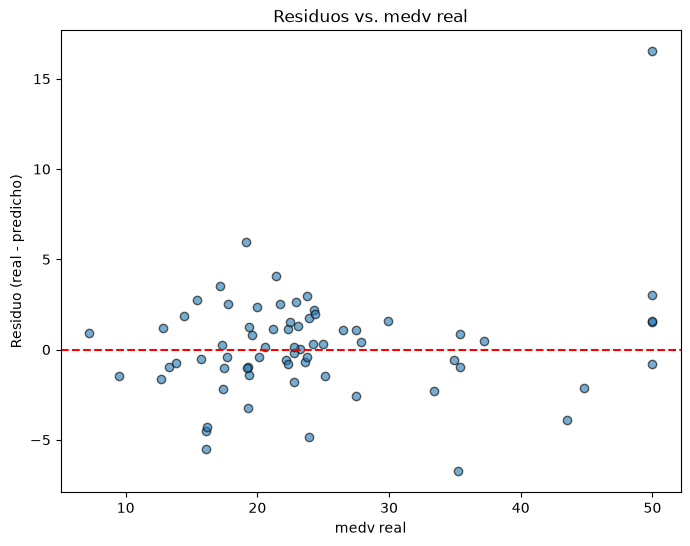

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, residuos, alpha=0.6, edgecolor="k")
ax.axhline(0, color="r", linestyle="--")
ax.set_xlabel("medv real")
ax.set_ylabel("Residuo (real - predicho)")
ax.set_title("Residuos vs. medv real")
plt.show()

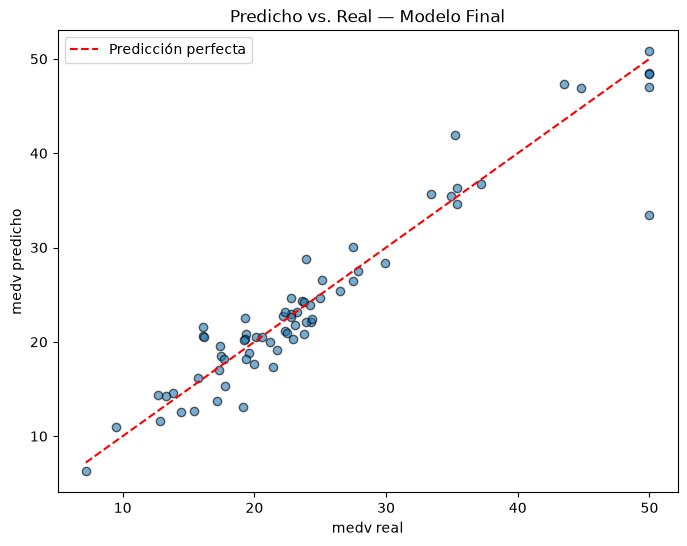

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, pred_test, alpha=0.6, edgecolor="k")
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predicción perfecta",
)
ax.set_xlabel("medv real")
ax.set_ylabel("medv predicho")
ax.set_title("Predicho vs. Real — Modelo Final")
ax.legend()
plt.show()

### ¿A qué se deben los errores?

In [16]:
x_test_analisis = x_test.copy()
x_test_analisis["error_absoluto"] = residuos.abs().values
x_test_analisis["medv_real"] = y_test.values

x_test_analisis.sort_values("error_absoluto", ascending=False)[
    ["boolean__chas", "medv_real", "error_absoluto"]
].head(10)

,boolean__chas,medv_real,error_absoluto
63,0.0,50.0,16.513318
61,1.0,35.2,6.754854
12,0.0,19.1,5.959457
37,0.0,16.1,5.518082
62,0.0,23.9,4.844849
13,0.0,16.1,4.511632
55,0.0,16.2,4.301034
22,0.0,21.4,4.063526
64,0.0,43.5,3.878112
33,0.0,17.2,3.512800


In [17]:
x_test_analisis.sort_values("error_absoluto", ascending=False)[
    ["log__crim", "medv_real", "error_absoluto"]
].head(10)

,log__crim,medv_real,error_absoluto
63,1.511222,50.0,16.513318
61,-0.605653,35.2,6.754854
12,1.991731,19.1,5.959457
37,0.480448,16.1,5.518082
62,-0.746507,23.9,4.844849
13,1.194328,16.1,4.511632
55,-0.580156,16.2,4.301034
22,1.914149,21.4,4.063526
64,-0.374840,43.5,3.878112
33,1.315135,17.2,3.512800


### Verificación de hipótesis alternativas — chas y crim

**`chas`:** 9 de los 10 peores errores tienen `chas=False`; el único caso con `chas=True`
está apenas por encima de su proporción esperada en el dataset (~6%). No hay evidencia de
que el desbalance de esta variable genere errores sistemáticos.

**`crim`:** los valores de `log__crim` en los peores errores están distribuidos en ambos
extremos (altos y bajos), sin ningún patrón direccional. Se descarta como causa sistemática
de error, incluso considerando que ya tiene outliers corregidos vía log-transform desde el
Paso 4.

**Conclusión:** la única causa identificable y confirmada de un error atípicamente grande es
la censura en `medv=50` (un solo caso, responsable de ~11% del MAE total). El resto de los
errores del modelo (rango 3.5-6.8) no muestra ningún patrón sistemático adicional —
consistente con variabilidad natural esperada de un modelo con MAE promedio de 1.98.

**Interpretación de las verificaciones:**

- **Censura en `medv=50`:** [completar tras correr — ¿cuántos de los 10 peores errores tienen medv_real==50?]
- **Desbalance de `chas`:** [completar — ¿los peores errores coinciden con chas=True?]
- **Outliers en `crim`:** [completar — ¿los peores errores coinciden con valores altos de log__crim?]

### ¿Cuáles son las consecuencias de las malas predicciones?

En un caso de uso real (tasación de vivienda, apoyo a decisiones de compra/venta o crédito
hipotecario), un error de MAE ~$1,980 implica:
- **Sobreestimación:** riesgo de que un comprador pague de más, o que un banco otorgue un
  crédito hipotecario por encima del valor real de garantía.
- **Subestimación:** riesgo de que un vendedor reciba una oferta injustamente baja.
- Los errores concentrados en el segmento de precios altos (por la censura en medv=50) son
  los de mayor consecuencia económica absoluta.

## 📊 Analysis of Results and Conclusions

### Feature Importance — confirmación cruzada

Dos métodos independientes (MDI y Permutation Importance) coinciden en el mismo ranking:
`lstat` y `rm` concentran ~80% de la importancia del modelo (MDI: 44.8% + 34.9%), seguidas
por `dis` con importancia moderada (5.4% MDI, 1.20 en unidades de MAE vía permutación). Esta
doble confirmación valida, con evidencia directa del modelo entrenado, lo que el análisis
exploratorio (Paso 3) ya sugería mediante correlaciones simples: `lstat` y `rm` son las
variables verdaderamente determinantes del precio de vivienda en este dataset.

`indus` y `zn` muestran importancia negativa en Permutation Importance — desordenarlas no
empeora el modelo, e incluso lo mejora marginalmente, confirmando que aportan ruido más que
señal.

### Learning Curve

El modelo reproduce exactamente los resultados de su optimización (Paso 6), confirmando
reproducibilidad completa entre el `.joblib` guardado y el proceso de entrenamiento
original. La brecha train-test se reduce progresivamente de 2.57 a 1.27 conforme crece el
tamaño de muestra, sin señales de overfitting descontrolado, gracias a la regularización
aplicada (`min_samples_leaf=5`, `subsample=0.7`).

### Análisis de errores

El hallazgo más significativo de este notebook es la **censura en `medv=50`**: un único
registro censurado (1.4% del set de test) genera el error más grande de toda la evaluación
(16.51, más de 2.4 veces el segundo peor error) y explica aproximadamente **11% del MAE
total del modelo** (1.98 con el caso incluido vs. 1.77 excluyéndolo).

Se descartaron dos hipótesis alternativas mediante verificación directa:
- **Desbalance de `chas`**: los peores errores no se concentran desproporcionadamente en
  `chas=True` (solo 1 de 10, cercano a su proporción real de ~6% en el dataset).
- **Outliers en `crim`**: los valores de criminalidad en los peores errores están
  distribuidos en ambos extremos, sin patrón direccional identificable.

El resto de los errores (rango 3.5-6.8, excluyendo el caso censurado) no muestra ningún
patrón sistemático adicional — es consistente con la variabilidad natural esperada de un
modelo con MAE promedio de 1.98.

### Consecuencias de las malas predicciones

En un caso de uso real de tasación inmobiliaria, un MAE de ~$1,980 implica riesgos
moderados y manejables en la mayoría de los casos, pero las predicciones en el segmento de
precios altos (donde ocurre la censura) tienen el mayor riesgo económico absoluto: tanto
para un comprador que podría pagar de más como para una entidad financiera que podría
sobrevalorar una garantía hipotecaria.

## 🧑‍🔬 Recomendaciones

1. **No ajustar el modelo específicamente para los casos censurados** — el problema radica
   en la calidad del dato de entrenamiento (precios reales >$50,000 registrados como
   exactamente 50.0), no en el algoritmo. Intentar "corregir" esto llevaría a sobreajuste.
2. **Reportar el MAE con y sin el caso censurado** en cualquier comunicación de resultados
   (1.98 vs. 1.77), para dar